In [1]:
# Loan Default Risk Analysis

In [2]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="dark", rc={
    "axes.facecolor": "#2b2b3d",
    "figure.facecolor": "#2b2b3d",
    "axes.labelcolor": "white",
    "xtick.color": "white",
    "ytick.color": "white",
    "text.color": "white"
})

import os
os.makedirs("images", exist_ok=True)
# warnings ignore
import warnings
warnings.filterwarnings('ignore')

# view full display
pd.set_option('display.max_columns',None)

In [3]:
# load data
b_data = pd.read_csv('/content/drive/MyDrive/A_Records/Loan_Defaulters/borrower_profiles.csv')
la_data = pd.read_csv('/content/drive/MyDrive/A_Records/Loan_Defaulters/loan_applications.csv')

- Borrower profiles data loaded as b_data
- Loan applications data loaded as la_data

In [4]:
# check the data shape
print(f"B_data had {b_data.shape[0]} rows and {b_data.shape[1]} columns")
print(f"La_data had {la_data.shape[0]} rows and {la_data.shape[1]} columns")

B_data had 500 rows and 11 columns
La_data had 601 rows and 12 columns


In [5]:
# functions
def basic_check(data):
  samples = data.head(3).T
  samples.rename(columns={0:'sample_1',1:'sample_2',2:'sample_3'},inplace=True)
  nulls_dups = pd.DataFrame({'dtypes':data.dtypes,'Missing':data.isnull().sum(),'Duplicates':data.duplicated().sum()})
  basic_check_result = pd.concat([nulls_dups,samples],axis = 1)
  return basic_check_result

def nums_cats(data):
  nums = data.select_dtypes(include='number').columns
  objs = data.select_dtypes(include='object').columns
  cats = data.select_dtypes(include='category').columns
  return nums, cats, objs

def vc(data,col):
  vc_count = data[col].value_counts()
  vc_percent = round(data[col].value_counts(normalize=True,dropna=True)*100,2)
  vc_result = pd.DataFrame({'counts':vc_count,
                            '%':vc_percent})
  return vc_result

In [6]:
b_data_check = basic_check(b_data)
b_data_check

,dtypes,Missing,Duplicates,sample_1,sample_2,sample_3
borrower_id,object,0,0,BRW-0001,BRW-0002,BRW-0003
age,int64,0,0,62,24,50
state,object,0,0,CT,CO,NC
education_level,object,0,0,High School,High School,Bachelor
employment_status,object,0,0,Self-Employed,Full-Time,Contract
years_employed,int64,0,0,6,4,22
annual_income,int64,0,0,31020,40188,41014
credit_score,int64,0,0,596,543,611
home_ownership,object,0,0,Rent,Own,Mortgage
dependents,int64,0,0,1,2,0


- No Missing Values and No Duplicates found in Borrowers data.
- All the  Data types are correct no need of any Adjustments.

In [7]:
la_data_check = basic_check(la_data)
la_data_check

,dtypes,Missing,Duplicates,sample_1,sample_2,sample_3
loan_id,object,0,0,LN-00001,LN-00002,LN-00003
borrower_id,object,0,0,BRW-0001,BRW-0001,BRW-0002
application_date,object,0,0,2024-01-08,2024-08-13,2025-06-28
loan_purpose,object,0,0,Vacation,Major Purchase,Moving
loan_amount,float64,0,0,16100.0,5600.0,44700.0
term_months,int64,0,0,36,48,36
interest_rate,float64,0,0,13.05,14.21,12.37
monthly_payment,float64,0,0,542.86,153.62,1492.59
dti_ratio,float64,0,0,55.5,40.4,70.5
loan_status,object,0,0,Paid Off,Default,Paid Off


In [8]:
print(f"Before conversion application date dtype: {la_data['application_date'].dtype}")
la_data['application_date'] = pd.to_datetime(la_data['application_date'])
print(f"After conversion application date dtype: {la_data['application_date'].dtype}")

Before conversion application date dtype: object
After conversion application date dtype: datetime64[ns]


- No Missing Values and No Duplicates found in Loan Applications data.
- All the  Data types are correct Except application date.
- Application date data type changed.

In [9]:
len(set(la_data['borrower_id']) - set(b_data['borrower_id']))

0

In [10]:
loan_borrows = pd.merge(la_data, b_data, on='borrower_id', how='inner')

# 1. Import and Explore
- Load both CSVs. ✔️
- Check for nulls, data types, and basic stats. ✔️
- Join the two tables on borrower_id. ✔️

In [11]:
loan_borrows.head()

,loan_id,borrower_id,application_date,loan_purpose,loan_amount,term_months,interest_rate,monthly_payment,dti_ratio,loan_status,days_delinquent,defaulted,age,state,education_level,employment_status,years_employed,annual_income,credit_score,home_ownership,dependents,existing_monthly_debt
0,LN-00001,BRW-0001,2024-01-08,Vacation,16100.0,36,13.05,542.86,55.5,Paid Off,0,0,62,CT,High School,Self-Employed,6,31020,596,Rent,1,892
1,LN-00002,BRW-0001,2024-08-13,Major Purchase,5600.0,48,14.21,153.62,40.4,Default,138,1,62,CT,High School,Self-Employed,6,31020,596,Rent,1,892
2,LN-00003,BRW-0002,2025-06-28,Moving,44700.0,36,12.37,1492.59,70.5,Paid Off,0,0,24,CO,High School,Full-Time,4,40188,543,Own,2,869
3,LN-00004,BRW-0003,2025-05-18,Auto Loan,9200.0,48,11.18,238.58,59.8,Default,34,1,50,NC,Bachelor,Contract,22,41014,611,Mortgage,0,1806
4,LN-00005,BRW-0004,2025-03-24,Moving,11200.0,36,9.66,359.61,44.1,Current,0,0,43,TX,High School,Full-Time,19,35036,701,Mortgage,2,928


In [12]:
loan_borrows.shape

(601, 22)

In [13]:
for col in loan_borrows.columns:
  if loan_borrows[col].dtype == 'O':
    print(col,":",loan_borrows[col].nunique())

loan_id : 601
borrower_id : 500
loan_purpose : 10
loan_status : 4
state : 30
education_level : 5
employment_status : 5
home_ownership : 3


In [14]:
req_cat_cols = ['loan_purpose','loan_status','education_level','employment_status','home_ownership']

for col in req_cat_cols:
    loan_borrows[col] = loan_borrows[col].astype('category')

In [15]:
# Bins for creditscore
loan_borrows['credit_score'].describe()

,credit_score
count,601.000000
mean,705.745424
std,98.216462
min,528.000000
25%,617.000000
50%,707.000000
75%,796.000000
max,850.000000


In [16]:
# Credit score range : 520–599, 600–649, 650–699, 700–749, 750+
labels = ['520–599', '600–649', '650–699', '700–749', '750+']
bins = [520,600,650,700,750,float('inf')]
loan_borrows['credit_score_bins'] = pd.cut(x=loan_borrows['credit_score'],bins = bins,labels = labels,include_lowest=True,right=False)

In [17]:
# Bins for DTI range
loan_borrows['dti_ratio'].describe()

,dti_ratio
count,601.000000
mean,49.680699
std,24.113652
min,7.600000
25%,32.200000
50%,48.100000
75%,62.400000
max,177.400000


In [18]:
# DTI Ratio : 5-24,25-49,50-74,75-99,100-124,125-149,150-174,175+
bins = [5,25,50,75,100,125,150,175,float('inf')]
labels = ['5–24','25–49','50–74','75–99','100–124','125–149','150–174','175+']
loan_borrows['dti_bins'] = pd.cut(x=loan_borrows['dti_ratio'],bins=bins,labels=labels,include_lowest=True,right=False)

In [19]:
nums , cats , objs = nums_cats(loan_borrows)
print(f"Number of Numerical columns:{len(nums)}")
print(f"Number of Categorical columns:{len(cats)}")
print(f"Number of Objects columns:{len(objs)}")


Number of Numerical columns:13
Number of Categorical columns:7
Number of Objects columns:3


In [20]:
loan_borrows.shape

(601, 24)

In [21]:
basic_check(loan_borrows)

,dtypes,Missing,Duplicates,sample_1,sample_2,sample_3
loan_id,object,0,0,LN-00001,LN-00002,LN-00003
borrower_id,object,0,0,BRW-0001,BRW-0001,BRW-0002
application_date,datetime64[ns],0,0,2024-01-08 00:00:00,2024-08-13 00:00:00,2025-06-28 00:00:00
loan_purpose,category,0,0,Vacation,Major Purchase,Moving
loan_amount,float64,0,0,16100.0,5600.0,44700.0
term_months,int64,0,0,36,48,36
interest_rate,float64,0,0,13.05,14.21,12.37
monthly_payment,float64,0,0,542.86,153.62,1492.59
dti_ratio,float64,0,0,55.5,40.4,70.5
loan_status,category,0,0,Paid Off,Default,Paid Off




* Loaded borrower and loan datasets and checked basic structure (rows, columns).
* Verified data quality: no missing values or duplicates found in both datasets.
* Converted application_date from object to datetime format.
* Checked borrower_id consistency and confirmed no mismatches between tables.
* Merged both datasets using borrower_id with an inner join (601 rows, 22 columns).
* Converted relevant columns into categorical type to improve efficiency.
* Created feature bins for credit_score and dti_ratio for risk segmentation.
* Final dataset is clean, merged, and ready for analysis or model building.




In [22]:
# lets check the category columns with Target columns
for col in cats:
  print(col,":",loan_borrows[col].nunique())

loan_purpose : 10
loan_status : 4
education_level : 5
employment_status : 5
home_ownership : 3
credit_score_bins : 5
dti_bins : 8


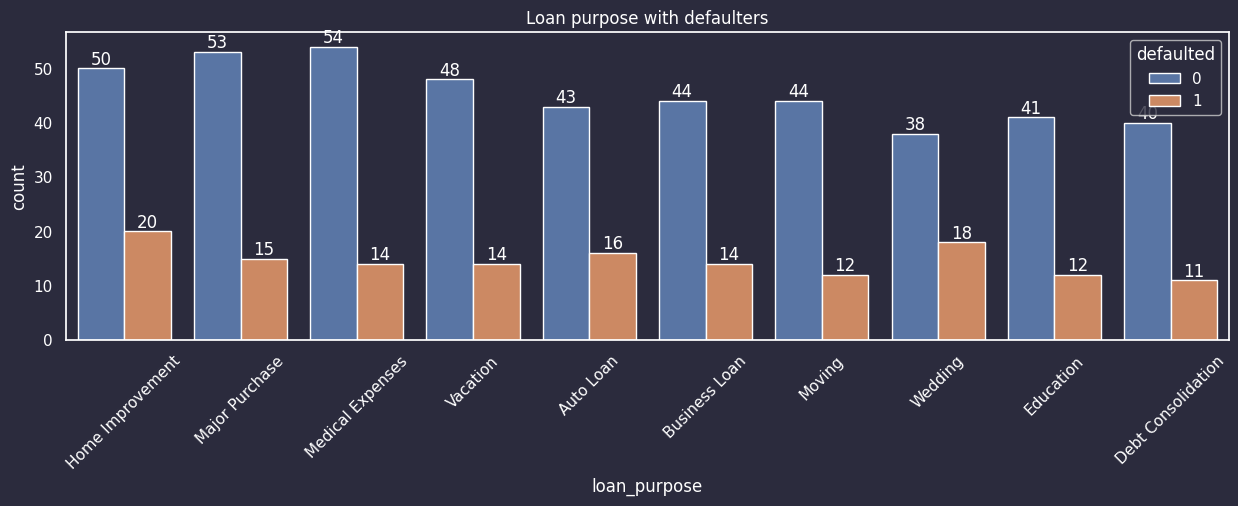

In [23]:
plt.figure(figsize=(15,4))
order = loan_borrows['loan_purpose'].value_counts().index
ax = sns.countplot(data=loan_borrows,x='loan_purpose',hue='defaulted',order=order)
ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])
plt.title('Loan purpose with defaulters')
plt.xticks(rotation= 45)
plt.savefig("images/loan_purpose.png", bbox_inches='tight')
plt.show()

In [24]:
round(loan_borrows.groupby('loan_purpose')['defaulted'].mean().mul(100).sort_values(ascending=False),2)


,defaulted
loan_purpose,
Wedding,32.14
Home Improvement,28.57
Auto Loan,27.12
Business Loan,24.14
Education,22.64
Vacation,22.58
Major Purchase,22.06
Debt Consolidation,21.57
Moving,21.43


- So the people who take loan for wedding and home improveent will have more defaulters and medical requiremets are less defaulters.

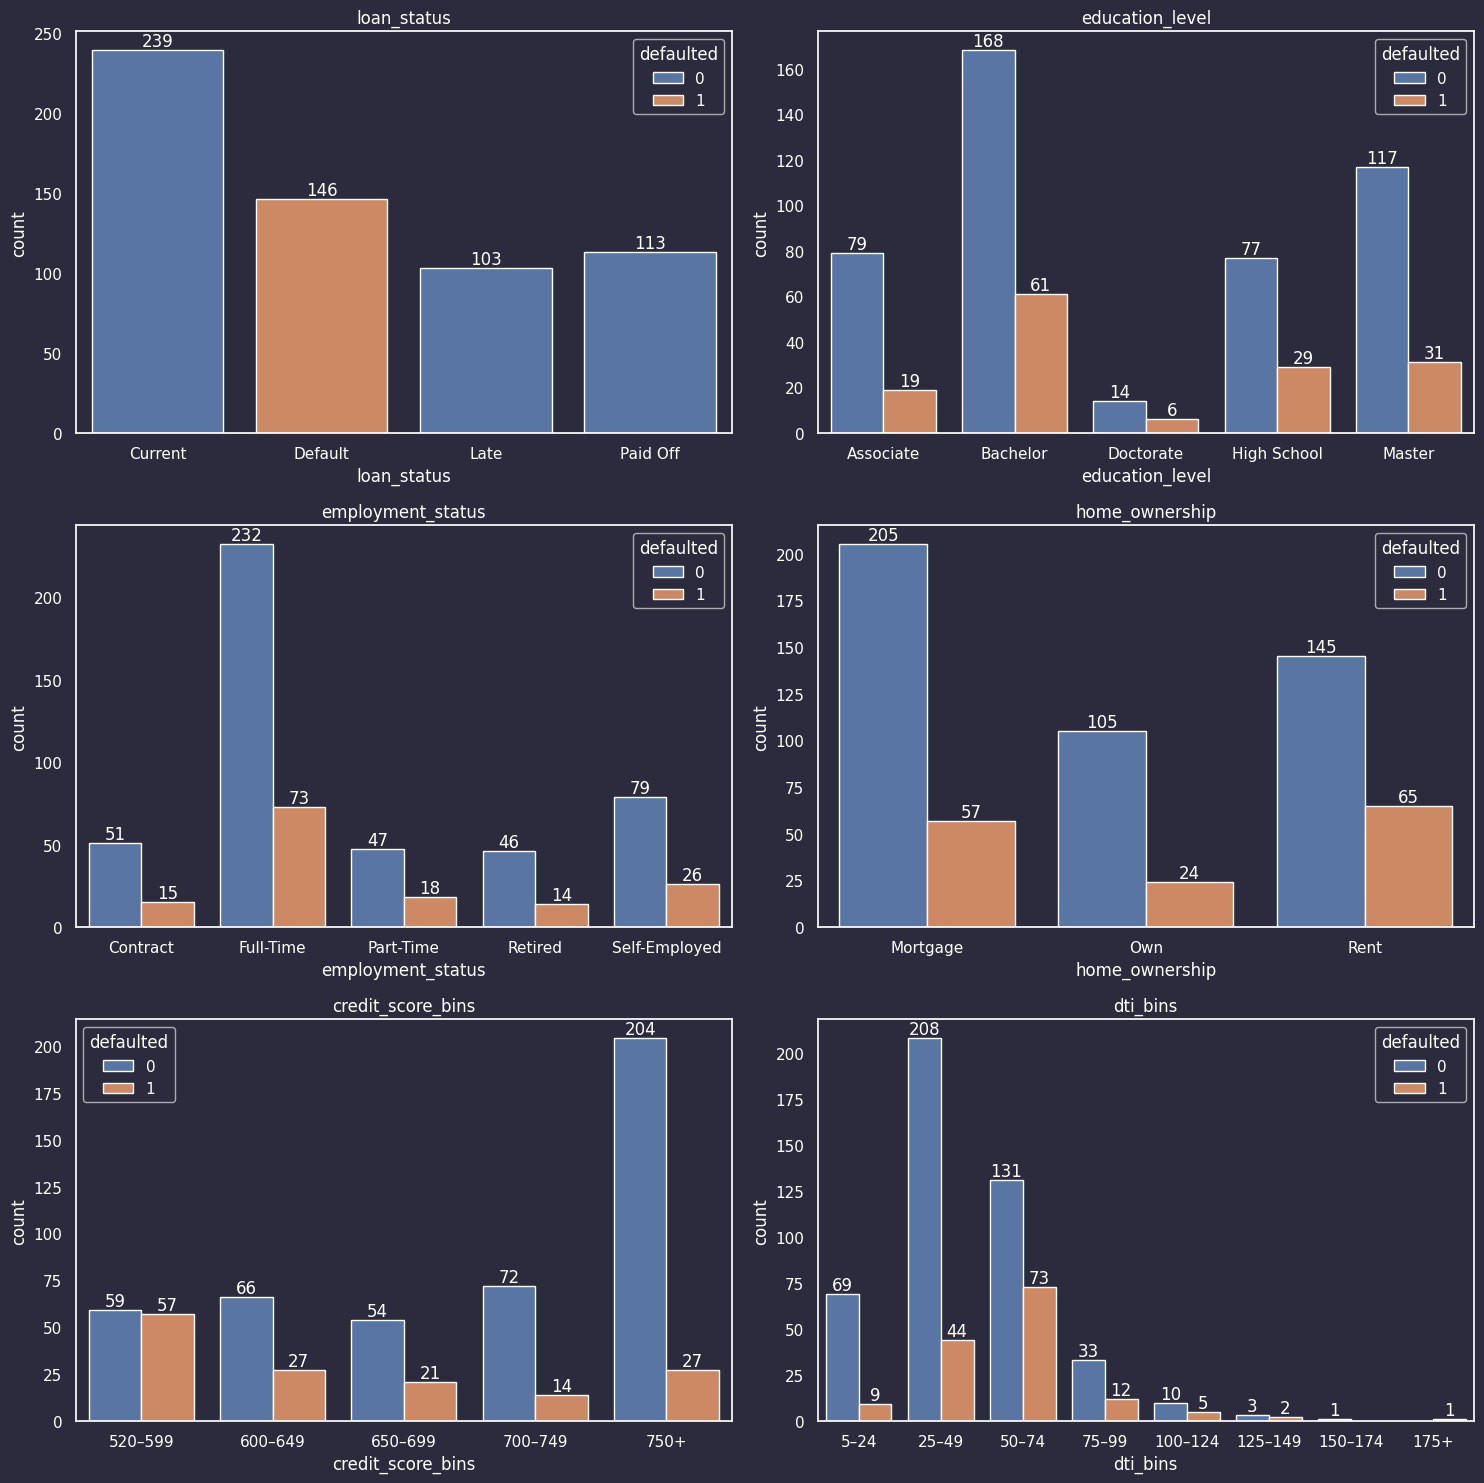

In [25]:
fig, axes = plt.subplots(3, 2, figsize=(15, 15))
axes = axes.flatten()

plot_index = 0
for col in cats:
    if col == 'loan_purpose':
        continue
    ax = sns.countplot(data=loan_borrows,x=col,hue='defaulted',ax=axes[plot_index])
    ax.set_title(col)
    for container in ax.containers:
        ax.bar_label(container)
    plot_index += 1

plt.tight_layout()
plt.savefig("images/category_analysis.png", bbox_inches='tight')
plt.show()

In [26]:
round(loan_borrows.groupby('home_ownership')['defaulted'].mean().mul(100).sort_values(),2)

,defaulted
home_ownership,
Own,18.60
Mortgage,21.76
Rent,30.95


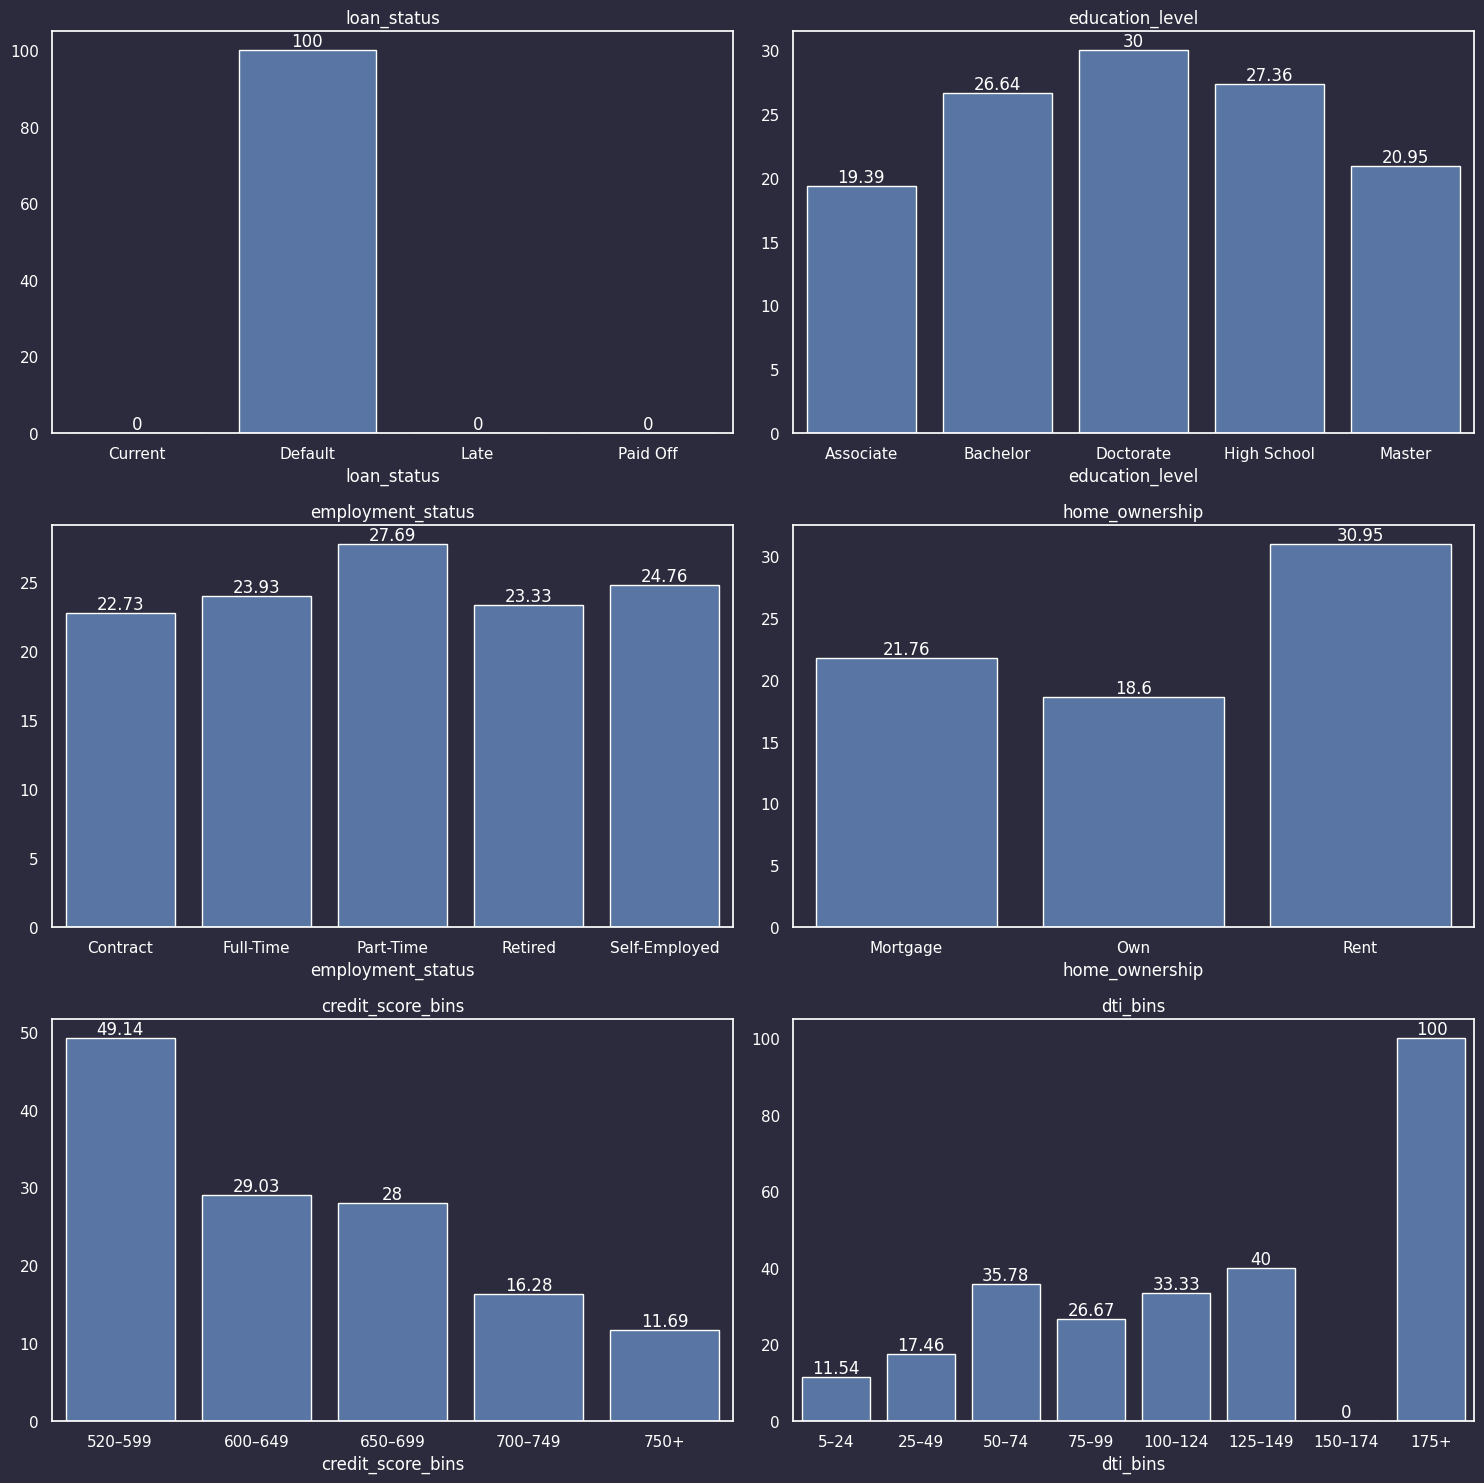

In [27]:
fig, axes = plt.subplots(3, 2, figsize=(15, 15))
axes = axes.flatten()

plot_index = 0
for col in cats:
    if col == 'loan_purpose':
        continue
    result = round(loan_borrows.groupby(col)['defaulted'].mean().mul(100).sort_values(),2)

    ax = sns.barplot(x=result.index,y=result.values,ax=axes[plot_index])
    ax.set_title(col)
    for container in ax.containers:
        ax.bar_label(container)
    plot_index += 1

plt.tight_layout()
plt.show()

## Observations

- Credit score shows a strong inverse relationship with default risk: higher scores (750+) have the lowest default rate, while lower scores (520–599) have the highest.  
- Debt-to-income (DTI) ratio is highly predictive, with default rates steadily increasing as DTI rises and peaking at extreme levels (175+).  
- Home ownership impacts risk: renters show the highest default rates, followed by mortgage holders, while owners have the lowest risk.  
- Employment status has a mild effect, with part-time and self-employed borrowers showing slightly higher default rates than full-time or contract workers.  
- Overall, financial health indicators (credit score and DTI) are much stronger predictors of default than demographic features.

# 2. Segment Analysis:
- Create credit score buckets and calculate default rates for each. ✔️
- Do the same for DTI ranges, employment status, and loan purpose.✔️

In [28]:
# correlation with target column
correlation_with_nums = loan_borrows[nums].corr()['defaulted']
correlation_with_nums

,defaulted
loan_amount,0.018116
term_months,-0.034632
interest_rate,0.198930
monthly_payment,0.061867
dti_ratio,0.192454
days_delinquent,0.881093
defaulted,1.000000
age,-0.006085
years_employed,-0.007199
annual_income,-0.081546


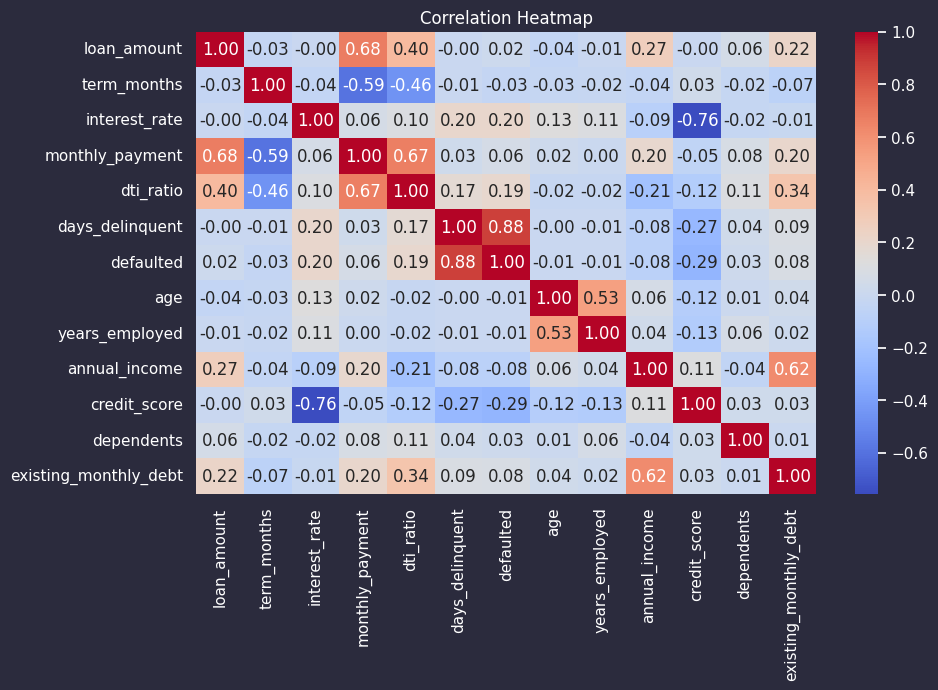

In [29]:

plt.figure(figsize=(10, 6))

corr = loan_borrows[nums].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")

plt.title("Correlation Heatmap")
plt.savefig("images/correlation_heatmap.png", bbox_inches='tight')
plt.show()

## Observations
- days_delinquent has the strongest positive correlation with defaulted (0.88), meaning past repayment delays are the best indicator of future default risk.  
- credit_score has a moderate negative correlation with defaulted (-0.29), meaning higher credit scores reduce the likelihood of default.  
- interest_rate has a weak positive correlation with defaulted (0.20), meaning riskier borrowers tend to be charged higher interest rates.  
- credit_score and interest_rate have a strong negative correlation (-0.76), meaning higher credit scores lead to lower interest rates (and vice versa).  
- dti_ratio shows a weak positive correlation with defaulted (0.19), meaning higher debt burden slightly increases default risk.  
- annual_income has a weak negative correlation with defaulted (-0.08), meaning higher income slightly reduces default risk.  
- loan_amount has almost no correlation with defaulted (0.02), meaning loan size does not strongly affect default probability in this dataset.  
- demographic features like age, dependents, and employment show near-zero correlation with defaulted, meaning minimal direct impact on risk.

# default rate by credit score range

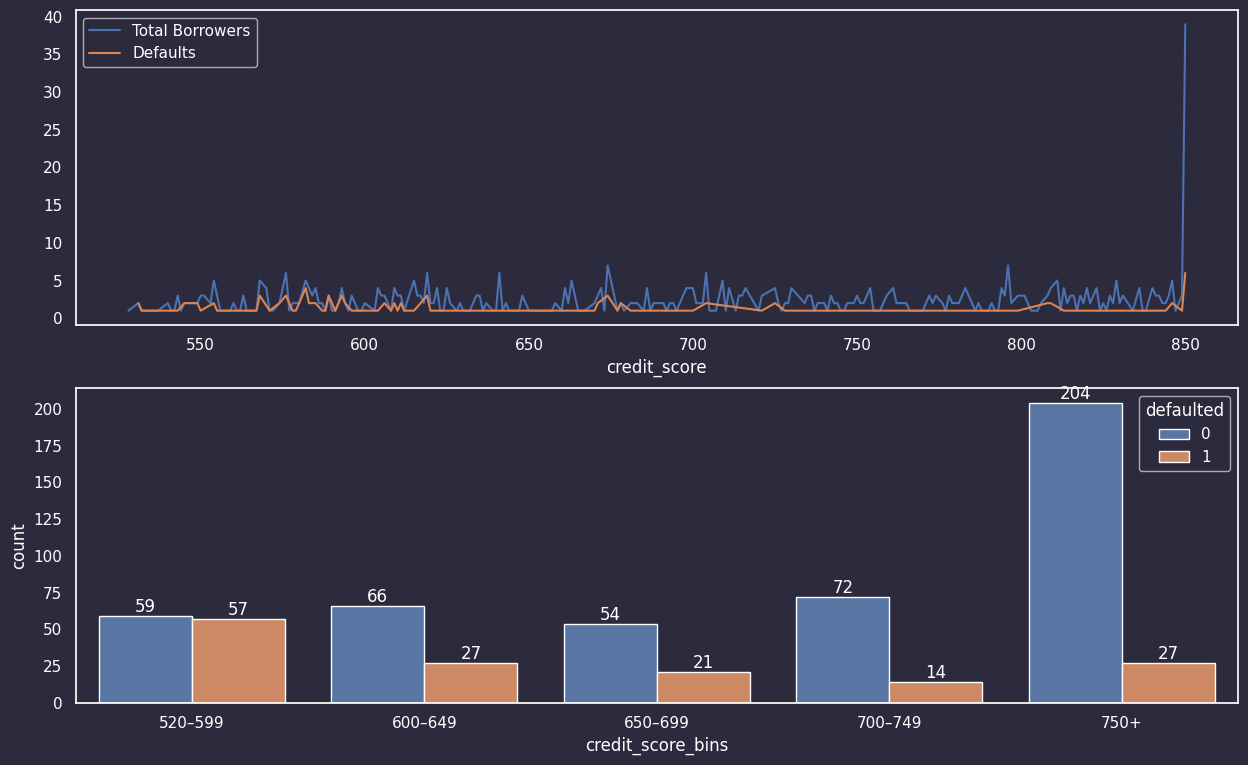

In [30]:
# credit score range
fig , axes = plt.subplots(2,1,figsize=(15,9))
axes=axes.flatten()

credit_total = loan_borrows['credit_score'].value_counts().sort_index()
credit_default = loan_borrows[loan_borrows['defaulted'] == 1]['credit_score'].value_counts().sort_index()

sns.lineplot(x=credit_total.index, y=credit_total.values, label="Total Borrowers" , ax=axes[0])
sns.lineplot(x=credit_default.index, y=credit_default.values, label="Defaults",ax=axes[0])

credit_score_bins = loan_borrows['credit_score_bins'].value_counts()
ax = sns.countplot(data = loan_borrows,x='credit_score_bins', hue='defaulted', ax = axes[1])
ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])

plt.savefig("images/credit_score_analysis.png", bbox_inches='tight')

plt.show()

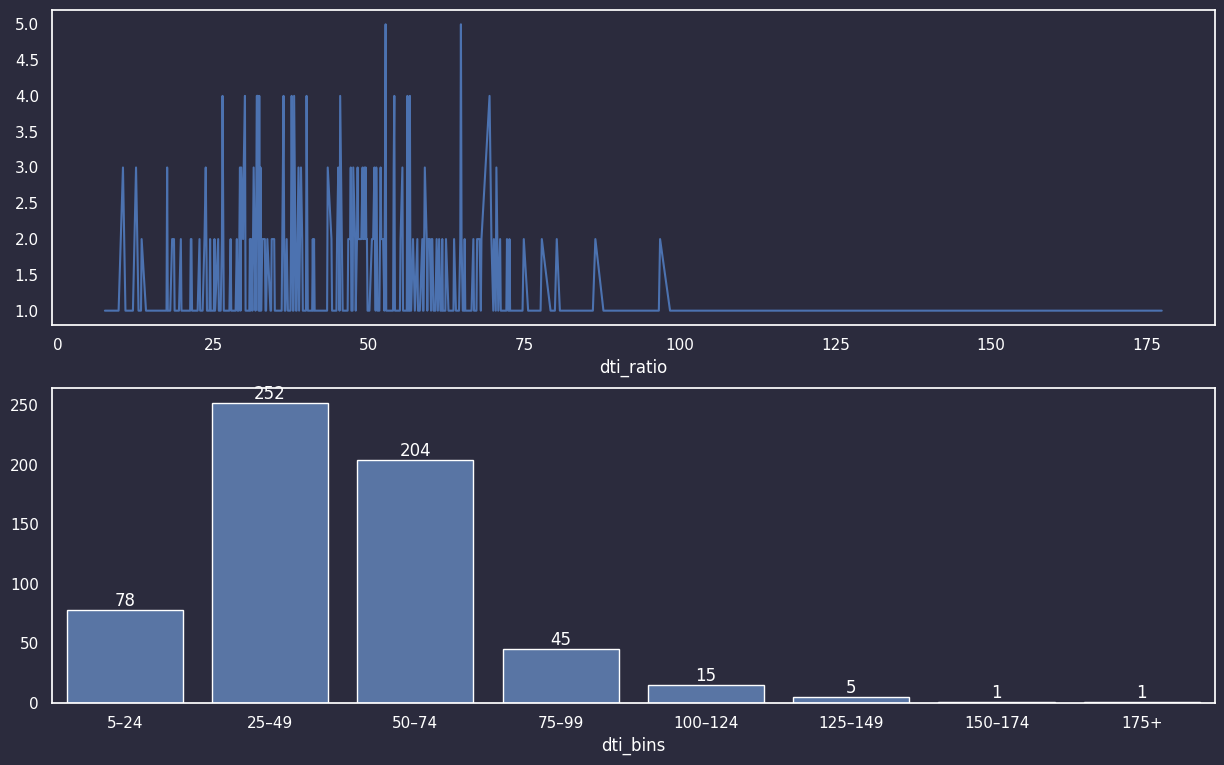

In [31]:
# dti vs defaults

fig , axes = plt.subplots(2,1,figsize=(15,9))
axes=axes.flatten()

dti_ratio_range = loan_borrows['dti_ratio'].value_counts()
sns.lineplot(x= dti_ratio_range.index , y = dti_ratio_range.values , ax = axes[0])

dti_ratio_bins = loan_borrows['dti_bins'].value_counts()
ax = sns.barplot(x= dti_ratio_bins.index , y = dti_ratio_bins.values , ax = axes[1])
ax.bar_label(ax.containers[0])
plt.show()

# scatter plot of DTI vs. default status

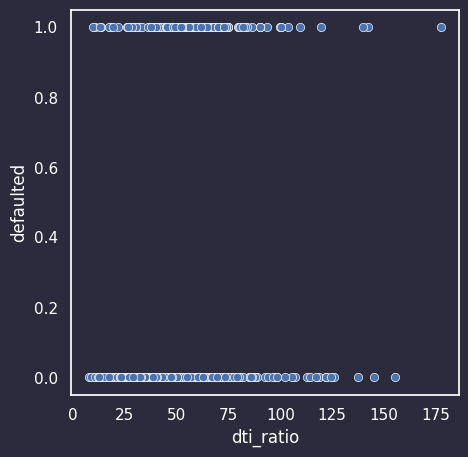

In [32]:
plt.figure(figsize=(5,5))
sns.scatterplot(y=loan_borrows['defaulted'],x=loan_borrows['dti_ratio'])
plt.savefig("images/dti_scatter.png", bbox_inches='tight')

plt.show()

# bar chart comparing loan purposes

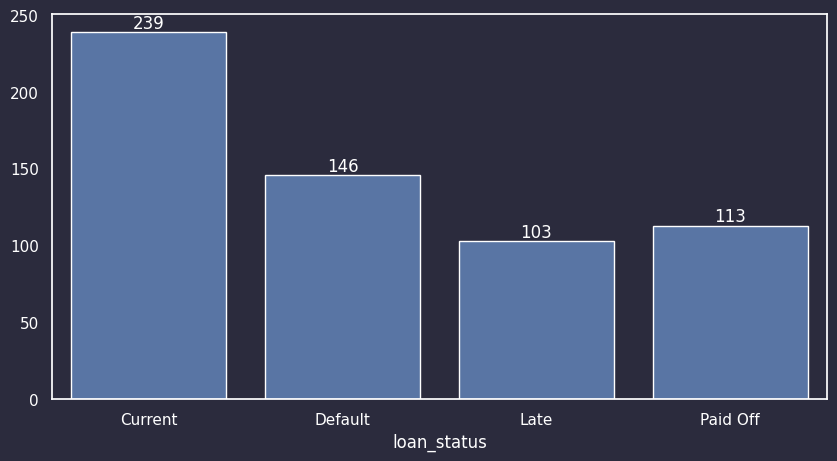

In [33]:
plt.figure(figsize=(10,5))
loan_status_range = loan_borrows['loan_status'].value_counts()
ax = sns.barplot(x= loan_status_range.index , y = loan_status_range.values)
ax.bar_label(ax.containers[0])
plt.savefig("images/loan_status.png", bbox_inches='tight')

plt.show()

# -------------------- SEGMENT ANALYSIS --------------------

### Credit Score Buckets:
- Default risk decreases steadily as credit score increases.
- 520–599 = highest risk group, 750+ = lowest risk group.
- Credit score is a strong separator of good vs bad borrowers.

### DTI Ranges:
- Higher DTI → higher default rate.
- Risk spikes sharply beyond high DTI levels.
- Strong indicator of financial stress.

### Employment Status:
- Self-employed and part-time borrowers show slightly higher defaults.
- Full-time/contract workers are comparatively safer.
- Moderate impact on default risk.

### Loan Purpose:
- Wedding and home improvement loans have higher defaults.
- Medical/essential loans show lower defaults.
- Loan purpose reflects borrower risk behavior.


# -------------------- CORRELATION ANALYSIS --------------------

- Strongest predictor: days_delinquent (~0.88)
- Credit score: moderate negative correlation (~ -0.29)
- DTI ratio: weak positive correlation (~0.19)
- Interest rate: weak positive correlation (~0.20)
- Income: weak negative correlation (~ -0.08)
- Loan amount: almost no correlation (~0.02)

- Key insight: behavioral + credit history dominate risk.

# -------------------- VISUALIZATION INSIGHTS --------------------

### Credit score vs default:
- Higher score → lower default risk.

### DTI vs default:
- Higher DTI → higher default probability.

### Loan purpose:
- Discretionary loans show higher defaults.


# -------------------- UNDERWRITING RECOMMENDATIONS --------------------

### Top 3 risk drivers:
- 1. Days delinquent
- 2. Credit score
- 3. DTI ratio

### Suggested rules:
- Credit score >= 650 preferred
- DTI <= 75 recommended
- Prior delinquency = high-risk flag

### Final takeaway:
- Financial behavior is stronger than demographic factors.